In [52]:
import psycopg2
import pandas as pd

# Database connection
def get_db_connection():
    return psycopg2.connect(
        dbname= 'Crypto_Data',
        user= 'postgres',
        password= 'harsh2505',
        host='localhost',
        port= '5432'
        )

# Fetch data as a DataFrame
def fetch_crypto_data():
    conn = get_db_connection()
    query = 'SELECT "timestamp", "price_usd", "market_cap", "volume" FROM crypto_prices ORDER BY "timestamp" ASC'
    df = pd.read_sql(query, conn)
    conn.close()
    return df

# Example usage
df = fetch_crypto_data()
print(df.head())


   timestamp     price_usd    market_cap        volume
0 2024-03-01  61298.216861  1.206725e+12  6.769269e+10
1 2024-03-02  62426.640529  1.227713e+12  3.669919e+10
2 2024-03-03  62067.866802  1.219383e+12  2.519821e+10
3 2024-03-04  63053.105439  1.236312e+12  2.710837e+10
4 2024-03-05  68186.645934  1.333913e+12  7.455171e+10


/var/folders/pk/p3wpx48n6vjf1t4q619jt4k40000gn/T/ipykernel_80112/3890076884.py:18: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



In [57]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
from keras_tuner import RandomSearch


In [56]:
pip install keras-tuner

Note: you may need to restart the kernel to use updated packages.


In [5]:
import plotly.express as px
import pandas as pd


# Convert timestamp to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Create an interactive line chart
fig = px.line(df, x="timestamp", y="price_usd", title="Bitcoin Price Trend", labels={"price_usd": "Price (USD)"})

# Show the interactive plot
fig.show()


In [6]:
import plotly.graph_objects as go

# Create subplots
fig = go.Figure()

# Price Line
# fig.add_trace(go.Scatter(x=df["timestamp"], y=df["price_usd"], mode="lines", name="Price (USD)", line=dict(color='blue')))

# Market Cap Line
fig.add_trace(go.Scatter(x=df["timestamp"], y=df["market_cap"], mode="lines", name="Market Cap", line=dict(color='green')))

# Volume Line
fig.add_trace(go.Scatter(x=df["timestamp"], y=df["volume"], mode="lines", name="Trading Volume", line=dict(color='red')))

# Layout
fig.update_layout(title="Crypto Market Trends", xaxis_title="Date", yaxis_title="Value", hovermode="x unified")

# Show Plot
fig.show()


In [7]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Candlestick(
    x=df["timestamp"],
    open=df["price_usd"],  # Replace with your 'open' column
    high=df["price_usd"] + 500,  # Simulated high values
    low=df["price_usd"] - 500,  # Simulated low values
    close=df["price_usd"],  # Replace with 'close' if available
    name="Bitcoin Candlestick Chart"
)])

fig.update_layout(title="Bitcoin Candlestick Chart", xaxis_title="Date", yaxis_title="Price (USD)")
fig.show()


In [8]:
df

,timestamp,price_usd,market_cap,volume
0,2024-03-01,61298.216861,1.206725e+12,6.769269e+10
1,2024-03-02,62426.640529,1.227713e+12,3.669919e+10
2,2024-03-03,62067.866802,1.219383e+12,2.519821e+10
3,2024-03-04,63053.105439,1.236312e+12,2.710837e+10
4,2024-03-05,68186.645934,1.333913e+12,7.455171e+10
...,...,...,...,...
350,2025-02-14,96561.663999,1.914315e+12,2.908437e+10
351,2025-02-15,97488.481485,1.931657e+12,3.228991e+10
352,2025-02-16,97569.951694,1.934308e+12,1.421531e+10
353,2025-02-17,96149.348455,1.905012e+12,1.363479e+10


In [25]:
df = df[['price_usd', 'market_cap', 'volume']]

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)


In [26]:
def create_dataset(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps - 1):
        X.append(data[i:(i + time_steps), :])
        y.append(data[i + time_steps, 0])  # Predicting 'price_usd'
    return np.array(X), np.array(y)

In [27]:
time_steps = 60
X, y = create_dataset(scaled_data, time_steps)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [18]:
split_ratio = 0.8
split = int(len(X) * split_ratio)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [28]:
model = Sequential()
model.add(LSTM(100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(50, return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(25, activation='relu'))
model.add(Dense(1))

/Users/harshshivhare/Documents/Real-Time-Crypto-Price-Prediction/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [29]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='mean_squared_error')


In [30]:
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - loss: 0.0918 - val_loss: 0.0487
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0185 - val_loss: 0.0340
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0120 - val_loss: 0.0662
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 0.0118 - val_loss: 0.0080
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 0.0082 - val_loss: 0.0280
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0079 - val_loss: 0.0111
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0084 - val_loss: 0.0066
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.0056 - val_loss: 0.0105
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 0.0067 - val_loss: 0.0073
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0058 - val_loss: 0.0070
Epoch 11/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 0.0060 - val_loss: 0.0070
Epoch 12/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0057 - val_lo

In [31]:
y_pred = model.predict(X_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step


In [32]:
y_test_rescaled = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), 2))), axis=1))[:, 0]
y_pred_rescaled = scaler.inverse_transform(np.concatenate((y_pred, np.zeros((len(y_pred), 2))), axis=1))[:, 0]

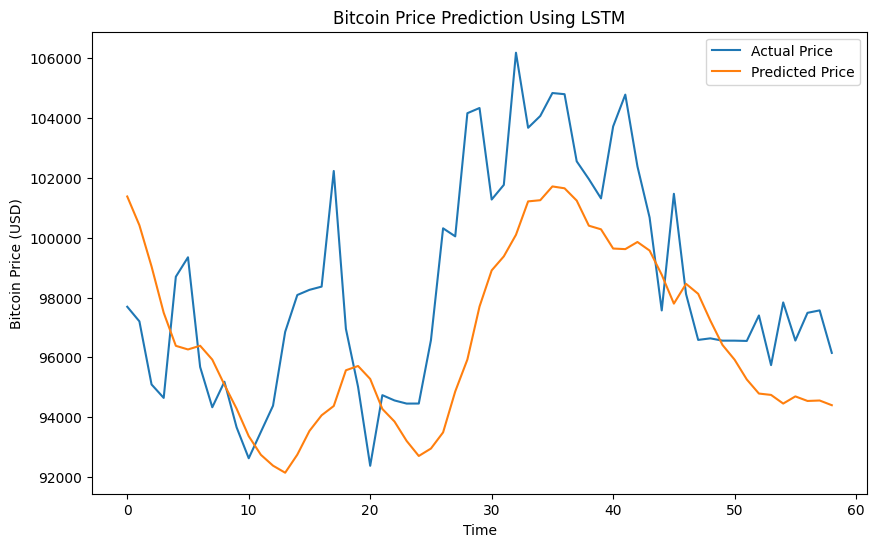

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled, label='Actual Price')
plt.plot(y_pred_rescaled, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price (USD)')
plt.title('Bitcoin Price Prediction Using LSTM')
plt.legend()
plt.show()

In [39]:
import plotly.express as px
import pandas as pd


# Convert timestamp to datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Create an interactive line chart
fig = px.line(df, x="timestamp", y="price_usd", title="Bitcoin Price Trend", labels={"price_usd": "Price (USD)"})

# Show the interactive plot
fig.show()


In [33]:
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
print(f'Root Mean Squared Error: {rmse:.4f}')

Root Mean Squared Error: 3293.5505


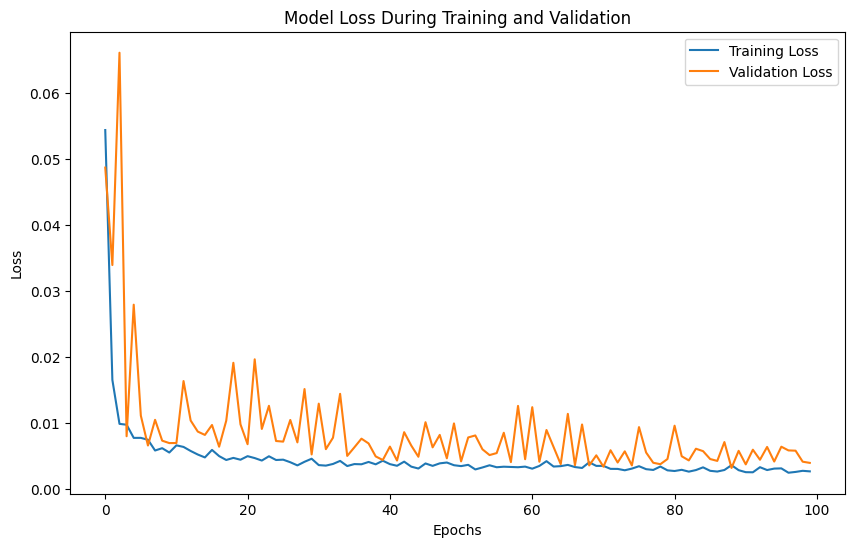

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss During Training and Validation')
plt.legend()
plt.show()

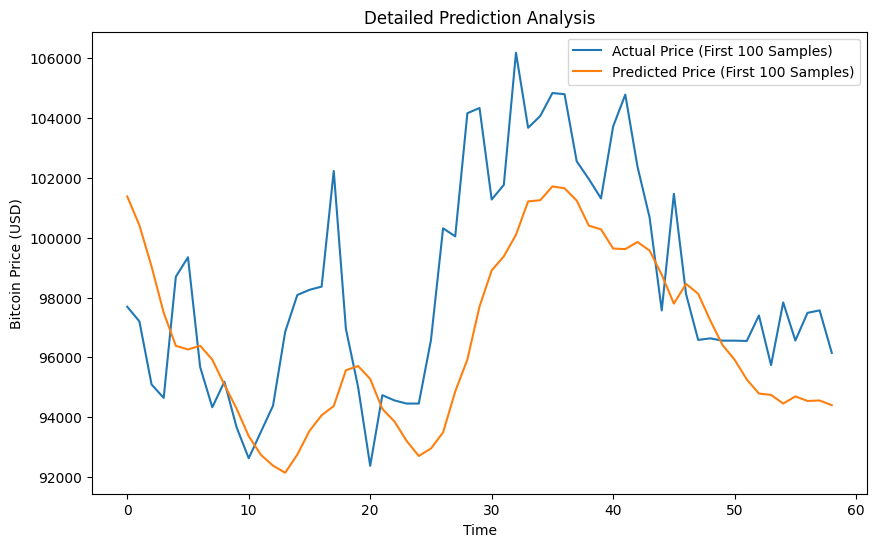

In [41]:
plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled[:100], label='Actual Price (First 100 Samples)')
plt.plot(y_pred_rescaled[:100], label='Predicted Price (First 100 Samples)')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price (USD)')
plt.title('Detailed Prediction Analysis')
plt.legend()
plt.show()

Epoch 1/200


/Users/harshshivhare/Documents/Real-Time-Crypto-Price-Prediction/.venv/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - loss: 0.1017

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 280ms/step - loss: 0.0989 - val_loss: 0.0444
Epoch 2/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0257

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - loss: 0.0254 - val_loss: 0.0309
Epoch 3/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - loss: 0.0224

...

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 0.0150 - val_loss: 0.0053
Epoch 8/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0135 - val_loss: 0.0102
Epoch 9/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0148 - val_loss: 0.0054
Epoch 10/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - loss: 0.0129

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0134 - val_loss: 0.0031
Epoch 11/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0135 - val_loss: 0.0046
Epoch 12/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0089 - val_loss: 0.0057
Epoch 13/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - loss: 0.0070 - val_loss: 0.0050
Epoch 14/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step - loss: 0.0108 - val_loss: 0.0051
Epoch 15/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - loss: 0.0095 

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - loss: 0.0095 - val_loss: 0.0031
Epoch 16/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - loss: 0.0100 - val_loss: 0.0070
Epoch 17/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0094 - val_loss: 0.0047
Epoch 18/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.0093

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step - loss: 0.0094 - val_loss: 0.0027
Epoch 19/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - loss: 0.0088 - val_loss: 0.0028
Epoch 20/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - loss: 0.0102 - val_loss: 0.0036
Epoch 21/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - loss: 0.0093 - val_loss: 0.0064
Epoch 22/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 0.0091 - val_loss: 0.0102
Epoch 23/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - loss: 0.0092 - val_loss: 0.0070
Epoch 24/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - loss: 0.0096 

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 126ms/step - loss: 0.0094 - val_loss: 0.0025
Epoch 25/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step - loss: 0.0110 - val_loss: 0.0064
Epoch 26/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - loss: 0.0064 - val_loss: 0.0176
Epoch 27/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - loss: 0.0092 - val_loss: 0.0164
Epoch 28/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 151ms/step - loss: 0.0058 - val_loss: 0.0052
Epoch 29/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - loss: 0.0066 - val_loss: 0.0051
Epoch 30/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step - loss: 0.0066 - val_loss: 0.0142
Epoch 31/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 153ms/step - loss: 0.0063 - val_loss: 0.0147
Epoch 32/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - loss: 0.0082 - val_loss: 0.0086
Epoch 33/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 145ms/step - loss: 0.0061 - val_loss: 0.0081
Epoch 34/200
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step - loss: 0.0059 - val_loss: 0.0137
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 338ms/step
Root Mean Squared Error: 263

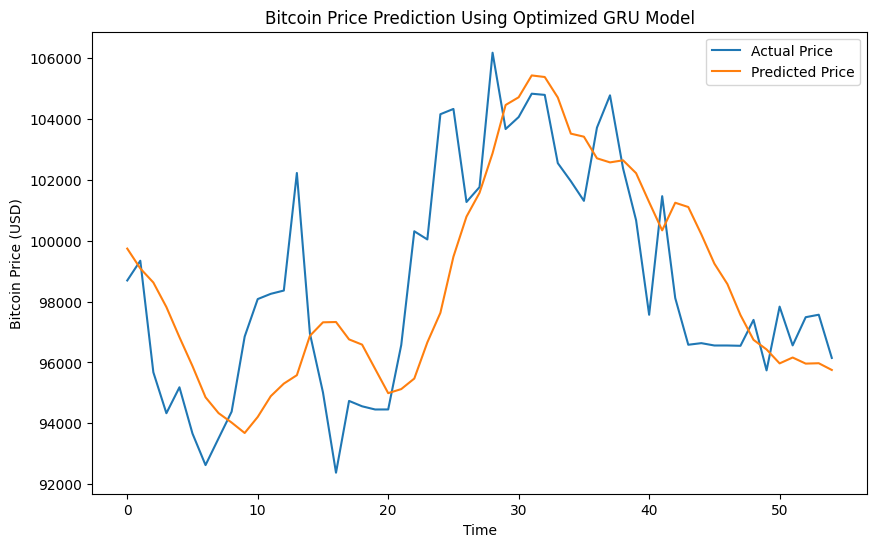

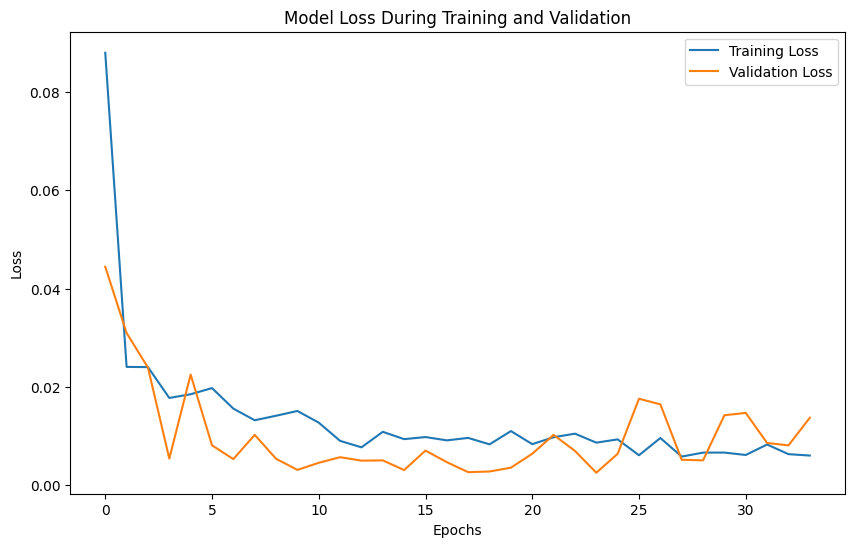

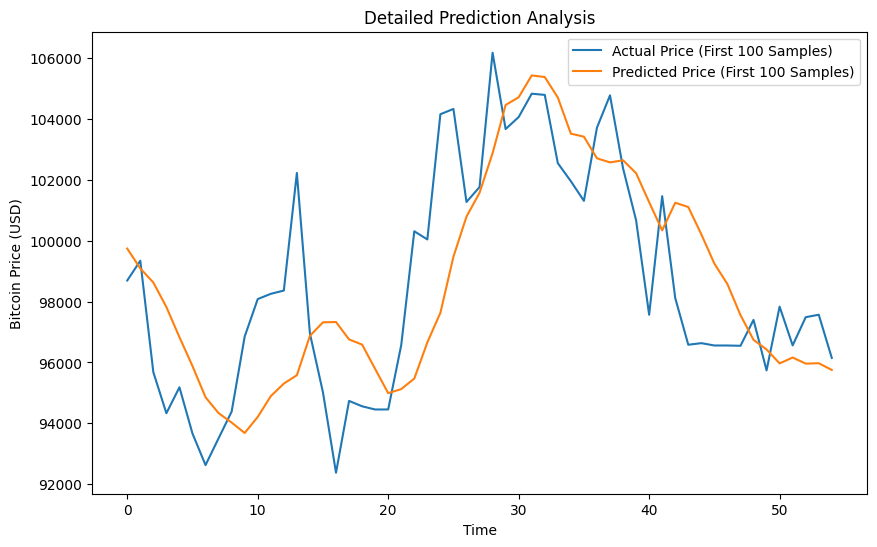

In [ ]:

from tensorflow.keras.layers import GRU, Dense, Dropout, Bidirectional


# Convert date to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Sort by date
df = df.sort_values('timestamp')

# Feature engineering with moving averages
df['MA7'] = df['price_usd'].rolling(window=7).mean()
df['MA21'] = df['price_usd'].rolling(window=21).mean()
df = df[['price_usd', 'market_cap', 'volume', 'MA7', 'MA21']].dropna()

# Normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

# Define a function to create a dataset with time steps
def create_dataset(data, time_steps=60):
    X, y = [], []
    for i in range(len(data) - time_steps - 1):
        X.append(data[i:(i + time_steps), :])
        y.append(data[i + time_steps, 0])  # Predicting 'price_usd'
    return np.array(X), np.array(y)

# Prepare the training and testing datasets
time_steps = 60
X, y = create_dataset(scaled_data, time_steps)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]


model = Sequential()
model.add(Bidirectional(GRU(100, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2]))))
model.add(Dropout(0.3))
model.add(Bidirectional(GRU(50, return_sequences=True)))
model.add(Dropout(0.3))
model.add(GRU(25, return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(25, activation='relu'))
model.add(Dense(1))

model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0005), loss='mean_squared_error')


early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True)


history = model.fit(X_train, y_train, epochs=200, batch_size=64, validation_data=(X_test, y_test),
                    verbose=1, callbacks=[early_stopping, model_checkpoint])


y_pred = model.predict(X_test)

y_test_rescaled = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), 4))), axis=1))[:, 0]
y_pred_rescaled = scaler.inverse_transform(np.concatenate((y_pred.reshape(-1, 1), np.zeros((len(y_pred), 4))), axis=1))[:, 0]


rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
print(f'Root Mean Squared Error: {rmse:.4f}')

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled, label='Actual Price')
plt.plot(y_pred_rescaled, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price (USD)')
plt.title('Bitcoin Price Prediction Using Optimized GRU Model')
plt.legend()
plt.show()

# Additional plots for research paper
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss During Training and Validation')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled[:100], label='Actual Price (First 100 Samples)')
plt.plot(y_pred_rescaled[:100], label='Predicted Price (First 100 Samples)')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price (USD)')
plt.title('Detailed Prediction Analysis')
plt.legend()
plt.show()


Trial 10 Complete [00h 00m 22s]
val_loss: 0.002148345345631242

Best val_loss So Far: 0.002148345345631242
Total elapsed time: 00h 02m 48s


/Users/harshshivhare/Documents/Real-Time-Crypto-Price-Prediction/.venv/lib/python3.12/site-packages/keras/src/saving/saving_lib.py:757: UserWarning:

Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 40 variables. 



2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 390ms/step
Root Mean Squared Error: 2422.2121


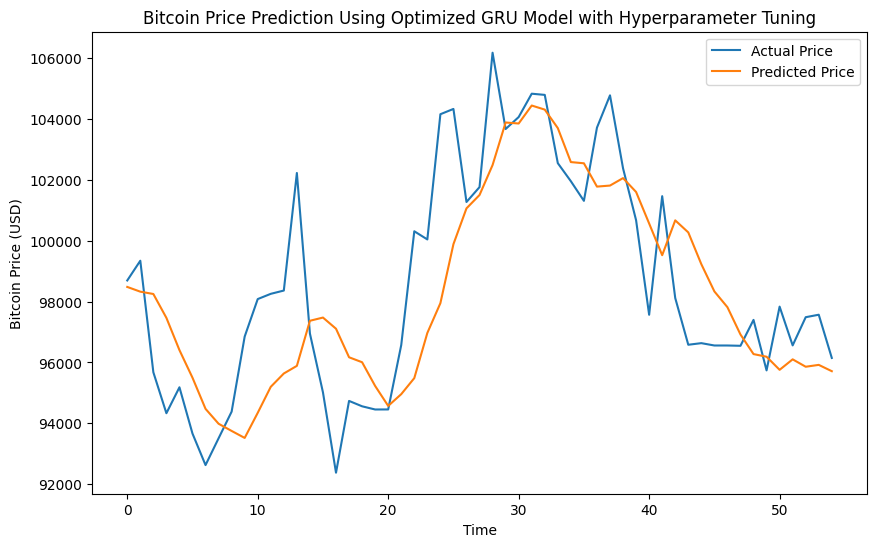

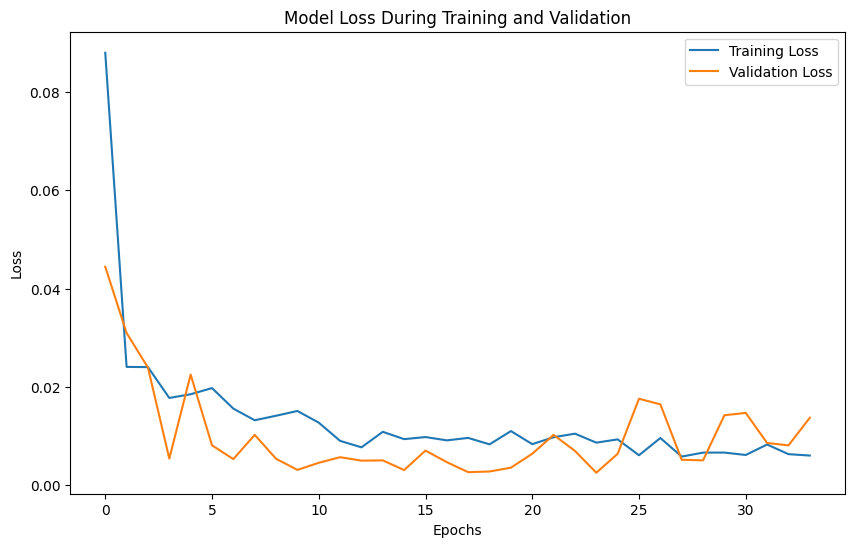

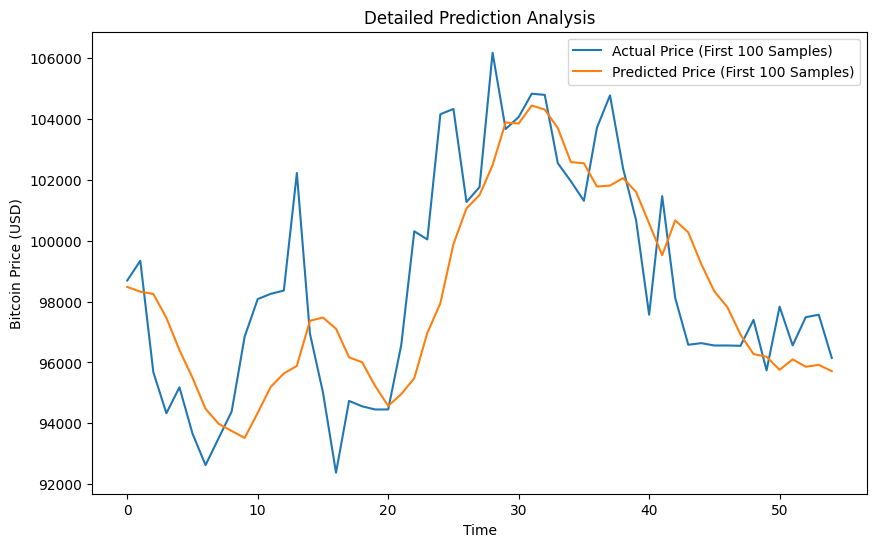

In [58]:
def build_model(hp):
    model = Sequential()
    model.add(Bidirectional(GRU(hp.Int('units1', min_value=50, max_value=200, step=50), return_sequences=True,
                               input_shape=(X_train.shape[1], X_train.shape[2]))))
    model.add(Dropout(hp.Float('dropout1', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Bidirectional(GRU(hp.Int('units2', min_value=25, max_value=100, step=25), return_sequences=True)))
    model.add(Dropout(hp.Float('dropout2', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(GRU(hp.Int('units3', min_value=10, max_value=50, step=10), return_sequences=False))
    model.add(Dropout(hp.Float('dropout3', min_value=0.1, max_value=0.5, step=0.1)))
    model.add(Dense(25, activation='relu'))
    model.add(Dense(1))
    model.compile(optimizer=keras.optimizers.Adam(hp.Choice('learning_rate', [1e-2, 1e-3, 1e-4])),
                  loss='mean_squared_error')
    return model

# Hyperparameter tuning
tuner = RandomSearch(build_model,
                     objective='val_loss',
                     max_trials=10,
                     executions_per_trial=1,
                     directory='hyperparameter_tuning',
                     project_name='crypto_price_prediction')

tuner.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test),
             callbacks=[EarlyStopping(monitor='val_loss', patience=5)])

# Get the best model
best_model = tuner.get_best_models(num_models=1)[0]

# Make predictions
y_pred = best_model.predict(X_test)

# Inverse scaling to get actual prices
y_test_rescaled = scaler.inverse_transform(np.concatenate((y_test.reshape(-1, 1), np.zeros((len(y_test), 4))), axis=1))[:, 0]
y_pred_rescaled = scaler.inverse_transform(np.concatenate((y_pred.reshape(-1, 1), np.zeros((len(y_pred), 4))), axis=1))[:, 0]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
print(f'Root Mean Squared Error: {rmse:.4f}')

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled, label='Actual Price')
plt.plot(y_pred_rescaled, label='Predicted Price')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price (USD)')
plt.title('Bitcoin Price Prediction Using Optimized GRU Model with Hyperparameter Tuning')
plt.legend()
plt.show()

# Additional plots for research paper
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss During Training and Validation')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(y_test_rescaled[:100], label='Actual Price (First 100 Samples)')
plt.plot(y_pred_rescaled[:100], label='Predicted Price (First 100 Samples)')
plt.xlabel('Time')
plt.ylabel('Bitcoin Price (USD)')
plt.title('Detailed Prediction Analysis')
plt.legend()
plt.show()

In [61]:
rmse = np.sqrt(mean_squared_error(y_test_rescaled, y_pred_rescaled))
r2 = r2_score(y_test_rescaled, y_pred_rescaled)
mape = mean_absolute_percentage_error(y_test_rescaled, y_pred_rescaled)
print(f'Root Mean Squared Error: {rmse:.4f}')
print(f'R² Score: {r2:.4f}')
print(f'Mean Absolute Percentage Error: {mape * 100:.2f}%')

Root Mean Squared Error: 2422.2121
R² Score: 0.5578
Mean Absolute Percentage Error: 1.90%


In [60]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_percentage_error


In [62]:
from sklearn.metrics import mean_absolute_error

# Calculate accuracy metrics
mae = mean_absolute_error(y_test_rescaled, y_pred_rescaled)
accuracy = 100 - np.mean(np.abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)) * 100

print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Accuracy: {accuracy:.2f}%')

Mean Absolute Error (MAE): 1879.1677
Accuracy: 98.10%


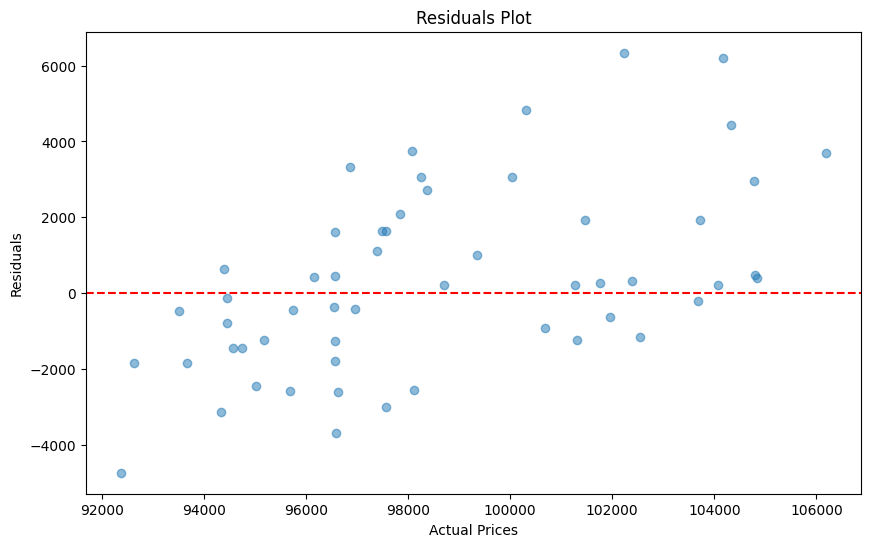

In [63]:
residuals = y_test_rescaled - y_pred_rescaled
plt.figure(figsize=(10, 6))
plt.scatter(y_test_rescaled, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Actual Prices')
plt.ylabel('Residuals')
plt.title('Residuals Plot')
plt.show()